<a href="https://colab.research.google.com/github/asit18/ai-ml/blob/main/california_housing_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
<class 'pandas.core.frame.DataFrame'>
Index: 16164 entries, 0 to 16999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 16164 non-null  float64
 1   latitude                  16164 non-nul

/tmp/ipykernel_29033/2048725011.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rooms_per_household'] = df['total_rooms'] / df['households']
/tmp/ipykernel_29033/2048725011.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['population_per_household'] = df['population'] / df['households']


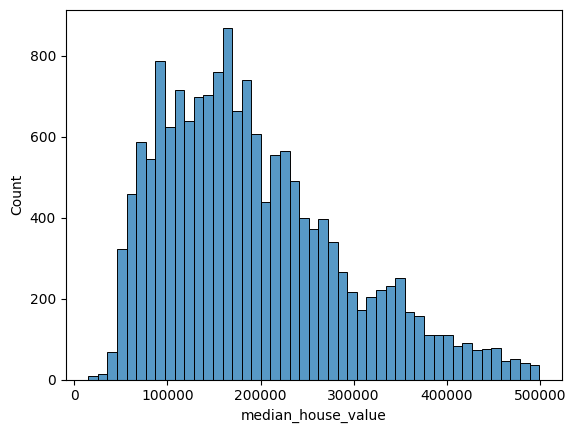

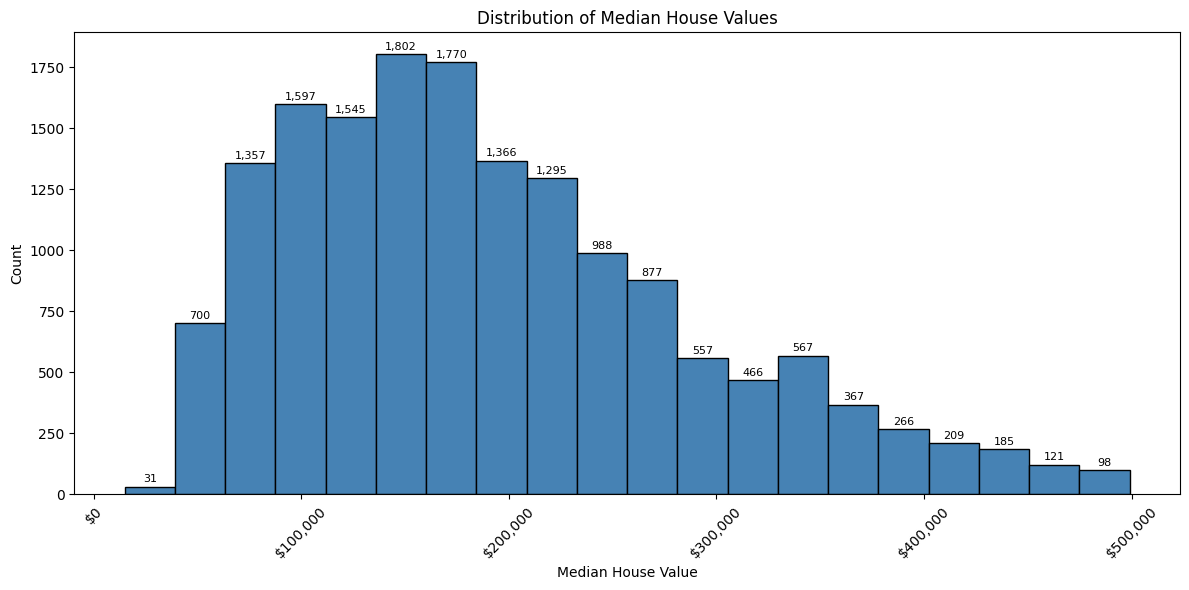

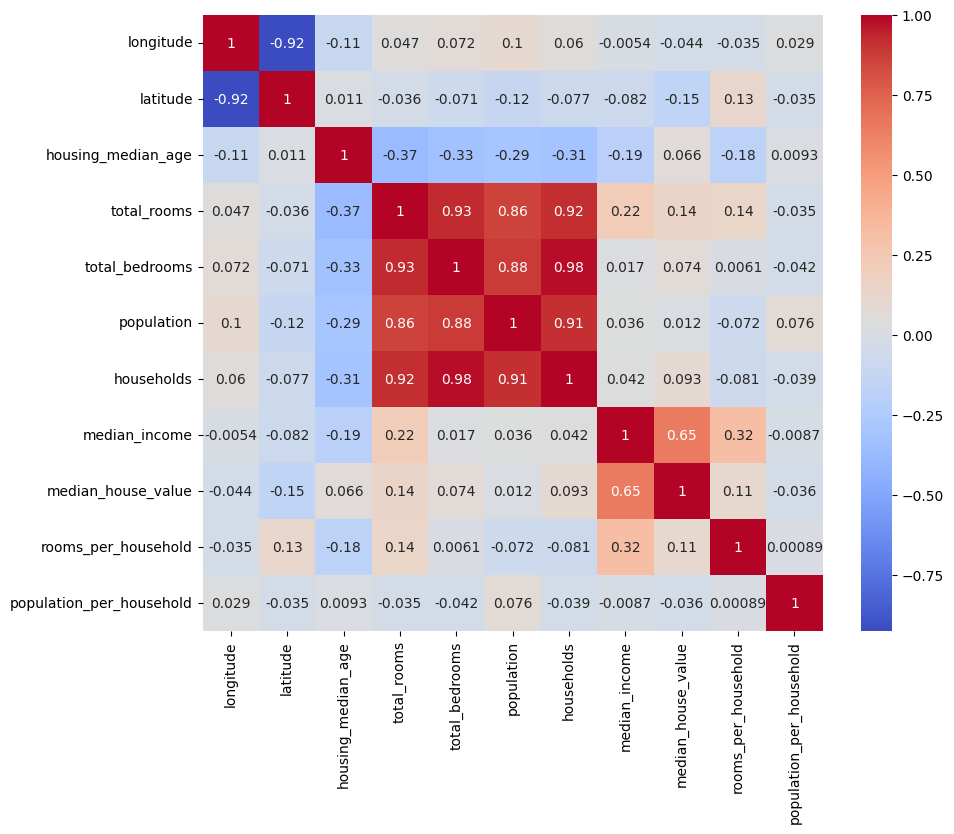

499100.0
(16164, 11)


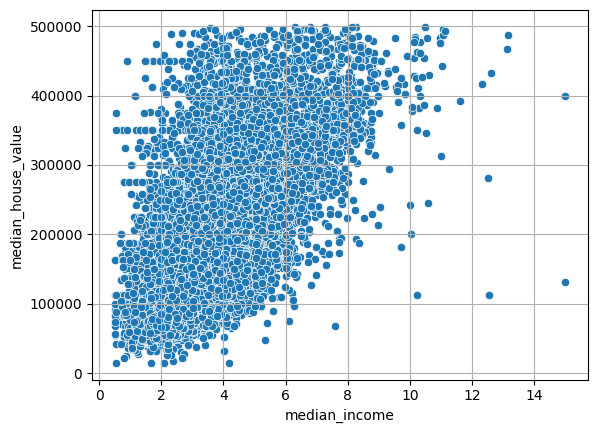

--- Degree 1 ---
  Coefficients: [ 3.44316218e+04 -4.72450662e+04 -4.55758953e+04  1.21416142e+00
  1.06994297e+03 -4.60525124e+02]
  Intercept: -3966270.7249760358
--- Degree 2 ---
  Coefficients: [-6.16033982e+05  8.64426312e+05  1.14708372e+06  1.00551836e+01
  2.86169129e+05  1.26097454e+06  1.08804676e+02 -7.57652671e+03
 -7.24873901e+03  4.80516990e-01  1.10972817e+03 -1.12258784e+03
  6.26793840e+03  1.53133412e+04 -3.81547076e-02  3.34407013e+03
  1.44032317e+04  8.39548004e+03 -9.47422973e-02  3.17913892e+03
  1.31887995e+04 -1.55711314e-05  5.55599359e-03 -4.03258061e+00
 -4.23763467e+01 -2.84977668e+03  8.50630109e+01]
  Intercept: 27532967.48444743
--- Degree 3 ---
  Coefficients: [-3.75958455e-01 -1.69097220e+00  2.90408584e+00  9.17042766e+00
  6.92202524e-01  2.28285444e-02 -1.17248814e-01  1.93668774e+01
  6.75382083e-01 -1.11635449e+02 -2.70788219e+00 -1.03497567e+00
  1.98820446e+02 -1.99214384e+02  2.23631017e+01 -4.49351601e+01
 -4.32194588e+00  7.87292329e+01  5.70

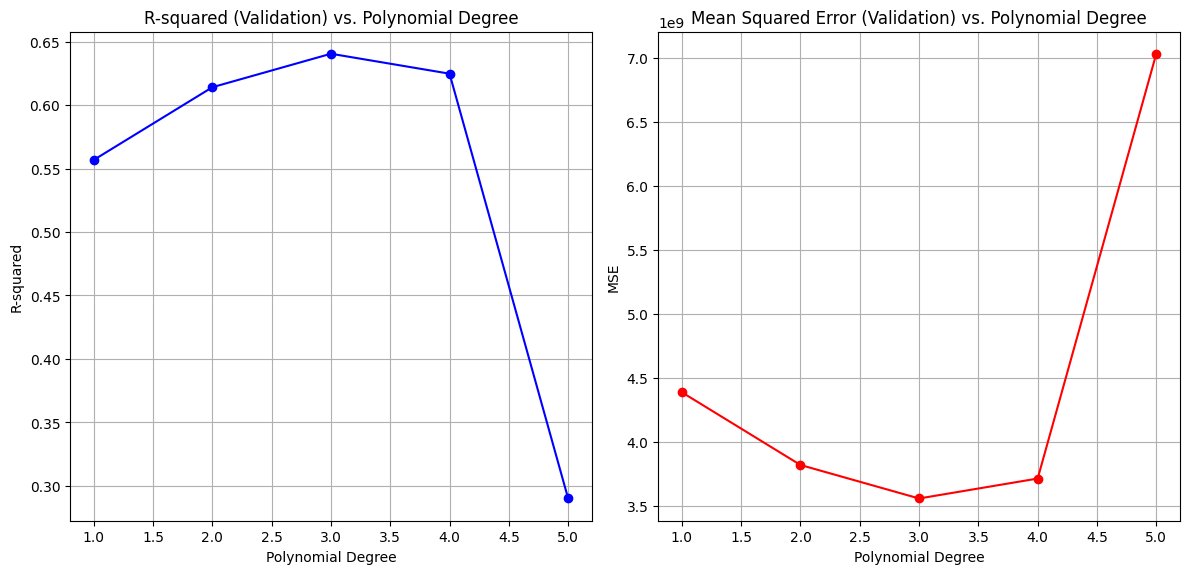

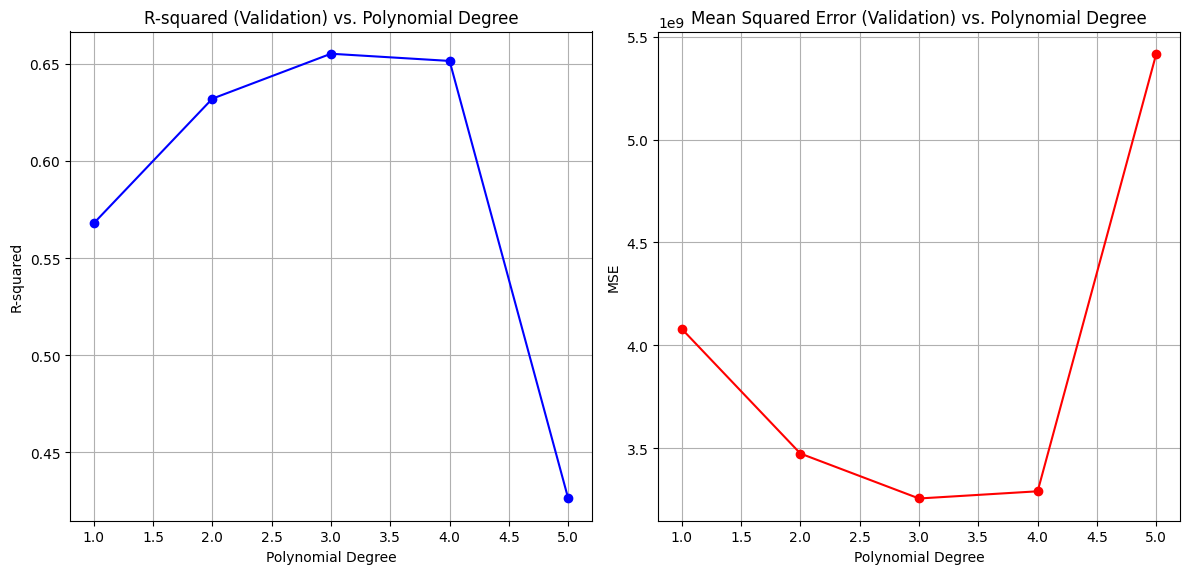

Final MSE: 3417916198.922748
Final R2: 0.6284511855900763


In [37]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import math # Added math import
import matplotlib.pyplot as plt
import seaborn as sns
import helper # Import the helper module
from sklearn.model_selection import train_test_split # Import train_test_split

def get_data_frame(file_path: str) -> pd.DataFrame:
    """Generates a sample data frame for a simple regression problem."""
    df = pd.read_csv(file_path)
    df.head()
    df.describe()
    df.info()
    df.shape
    df.columns
    return df
def clean_data(df:pd.DataFrame):

  df.dropna(inplace=True)
  df.drop_duplicates(inplace=True)
  df = df.query("median_house_value < 500000")
  df['rooms_per_household'] = df['total_rooms'] / df['households']
  df['population_per_household'] = df['population'] / df['households']
  df.describe()
  df.info()
  return df

# Removed heatmap, scatter_plot, histogram_prices from here, as they are now in helper.py

def build_pipeline(degree: int):
  poly_features = PolynomialFeatures(degree=degree, include_bias=False)
  lin_reg = LinearRegression()
  pipeline = Pipeline([
      ("poly_features", poly_features),
      ("lin_reg", lin_reg)
  ])
  return pipeline

def train_model(pipeline, X, y):
  return pipeline.fit(X, y)
def split_data(X: np.ndarray,y: np.ndarray , size: float):

  return train_test_split(X, y, test_size=size, random_state=42)

# Definition for scatter_plot_XY to plot R2 and MSE values
def scatter_plot_XY(r2_values: list, mse_values: list):
    degrees = list(range(1, len(r2_values) + 1))

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(degrees, r2_values, marker='o', linestyle='-', color='blue')
    plt.title('R-squared (Validation) vs. Polynomial Degree')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('R-squared')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(degrees, mse_values, marker='o', linestyle='-', color='red')
    plt.title('Mean Squared Error (Validation) vs. Polynomial Degree')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('MSE')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def ploy_reg(df: pd.DataFrame):
  r2_val_values = []
  mse_val_values = []
  r2_train_values = []
  mse_train_values = []
  for degree in range(1, 6):
    X = df[["median_income"]]
    y = df["median_house_value"]

    print(f"--- Degree {degree} ---")

    # Create a range of x values for plotting the regression lines
    X_range = pd.DataFrame(np.linspace(X["median_income"].min(), X["median_income"].max(), 100).reshape(-1, 1), columns=["median_income"])

    pipeline = build_pipeline(degree)
    # Use train_test_split for a proper split with different random states
    X_data = df[["median_income", "longitude", "latitude", "total_rooms", "rooms_per_household", "population_per_household"]]
    y_data = df["median_house_value"]
    X_temp, X_test, y_temp, y_test = split_data(X_data,y_data,0.2)
    X_train, X_val, y_train, y_val = split_data(X_temp, y_temp, 0.25)

    model = train_model(pipeline, X_train, y_train)
    mse = mean_squared_error(y_val, model.predict(X_val)) # Evaluate on validation set
    r2 = r2_score(y_val, model.predict(X_val))
    r2_train_values.append(r2_score(y_train, model.predict(X_train)))
    mse_train_values.append(mean_squared_error(y_train, model.predict(X_train)))
    r2_val_values.append(r2)       # Evaluate on validation set
    mse_val_values.append(mse)
    print(f"Train R²: {train_r2:.3f}")
    print(f"Val R²:   {val_r2:.3f}")
    print(f"Gap:      {train_r2 - val_r2:.3f}")

    # Get the LinearRegression model from the pipeline and print coefficients
    lin_reg_model = model.named_steps['lin_reg']
    print("  Coefficients:", lin_reg_model.coef_)
    print("  Intercept:", lin_reg_model.intercept_)

  # Call scatter_plot_XY outside the loop to plot the collected metrics
  scatter_plot_XY(r2_val_values, mse_val_values)
  scatter_plot_XY(r2_train_values, mse_train_values)
  pipeline = build_pipeline(3)
  X_data = df[["median_income", "longitude", "latitude", "total_rooms","rooms_per_household", "population_per_household"]]
  y_data = df["median_house_value"]
  X_train, X_test, y_train, y_test = split_data(X_data, y_data, 0.2)
  model = train_model(pipeline, X_train, y_train)
  mse = mean_squared_error(y_test, model.predict(X_test))
  r2 = r2_score(y_test, model.predict(X_test))
  print(f"Final MSE: {mse}")
  print(f"Final R2: {r2}")

def main():
  df = get_data_frame("sample_data/california_housing_train.csv")
  df = clean_data(df)

  # Calling functions from helper module
  helper.histogram_prices(df)
  helper.heatmap(df)
  print(df['median_house_value'].max())
  print(df.shape)
  helper.scatter_plot(df)
  ploy_reg(df)



if __name__ == '__main__':
    main()

In [38]:
%%writefile helper.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

def heatmap(df: pd.DataFrame):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.show()
def scatter_plot(df: pd.DataFrame):
    sns.scatterplot(data=df, x="median_income", y="median_house_value")
    plt.grid(True)
    plt.show()
def histogram_prices(df: pd.DataFrame):
    sns.histplot(df["median_house_value"])
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the histogram with fewer bins
    counts, edges, patches = ax.hist(
        df['median_house_value'],
        bins=20,                    # \u2190 fewer bins = wider bars
        edgecolor='black',          # \u2190 black border so bars are distinct
        color='steelblue'
    )

    # Add count labels on top of each bar
    for count, edge, patch in zip(counts, edges, patches):
        if count > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,  # center of bar
                patch.get_height() + 10,                  # just above bar
                f'{int(count):,}',                        # formatted number
                ha='center', va='bottom', fontsize=8
            )

    # Format x axis as dollar amounts
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
    )

    ax.set_xlabel('Median House Value')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Median House Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Overwriting helper.py


In [39]:
# This cell is to re-load the helper module after writing the file.
import importlib
import helper
importlib.reload(helper)


<module 'helper' from '/content/helper.py'>

The `helper.py` file has been created/updated, and the module reloaded. Now, let's fix the main code cell (`Uj6IUxbMtQiZ`) to correctly call these functions from `helper` and ensure the rest of the `ploy_reg` logic is as intended.